In [1]:
!pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 489.4 kB/s  0:00:28m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 719.9 kB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 794.1 kB/s  0:00:40m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-image] [scikit-image]


In [3]:
# Import the otsu threshold function
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt
from skimage import color
from skimage.filters import sobel

In [ ]:
def show_image(image, title='Original'):
  plt.figure()
  plt.imshow(image, cmap='gray')
  plt.title(title)
  plt.axis('off')
  plt.show()
  plt.figure()


## Edge detection

In [5]:
img = plt.imread('image.png')

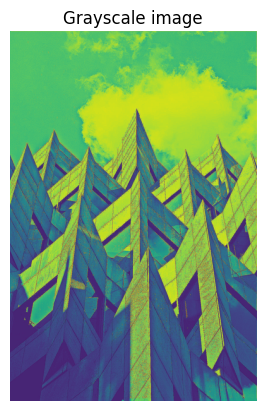

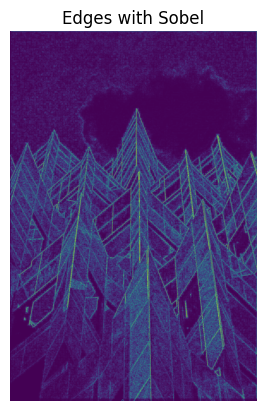

In [ ]:
# Import the color module

img = plt.imread('image.png')

# Make the image grayscale
soaps_image_gray = color.rgb2gray(img)

# Apply edge detection filter
edge_sobel = sobel(soaps_image_gray)

# Show original and resulting image to compare
show_image(soaps_image_gray, "Grayscale image")
show_image(edge_sobel, "Edges with Sobel")

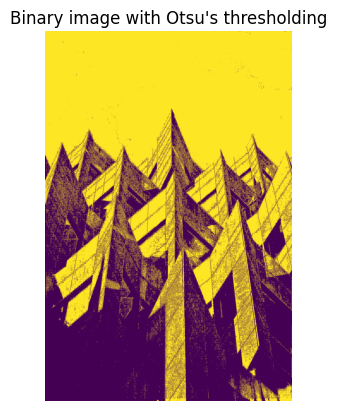

In [ ]:
# Make the image grayscale using rgb2gray
chess_pieces_image_gray = rgb2gray(img)

# Obtain the optimal threshold value with otsu
thresh = threshold_otsu(chess_pieces_image_gray)

# Apply thresholding to the image
binary = chess_pieces_image_gray > thresh

# Show the image
# remove axis
show_image(binary, "Binary image with Otsu's thresholding")

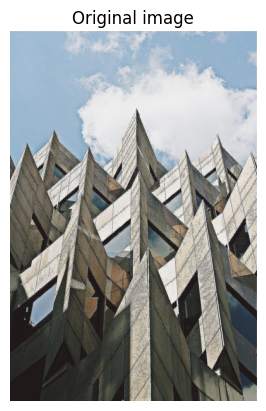

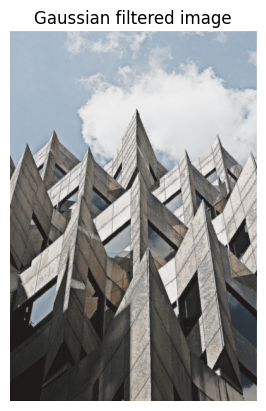

In [ ]:
# Import Gaussian filter 
from skimage.filters import gaussian

# Apply filter
gaussian_image = gaussian(img, sigma=1)

# Show original and resulting image to compare
show_image(img, "Original image")

show_image(gaussian_image, "Gaussian filtered image")

## Contrast enhancement

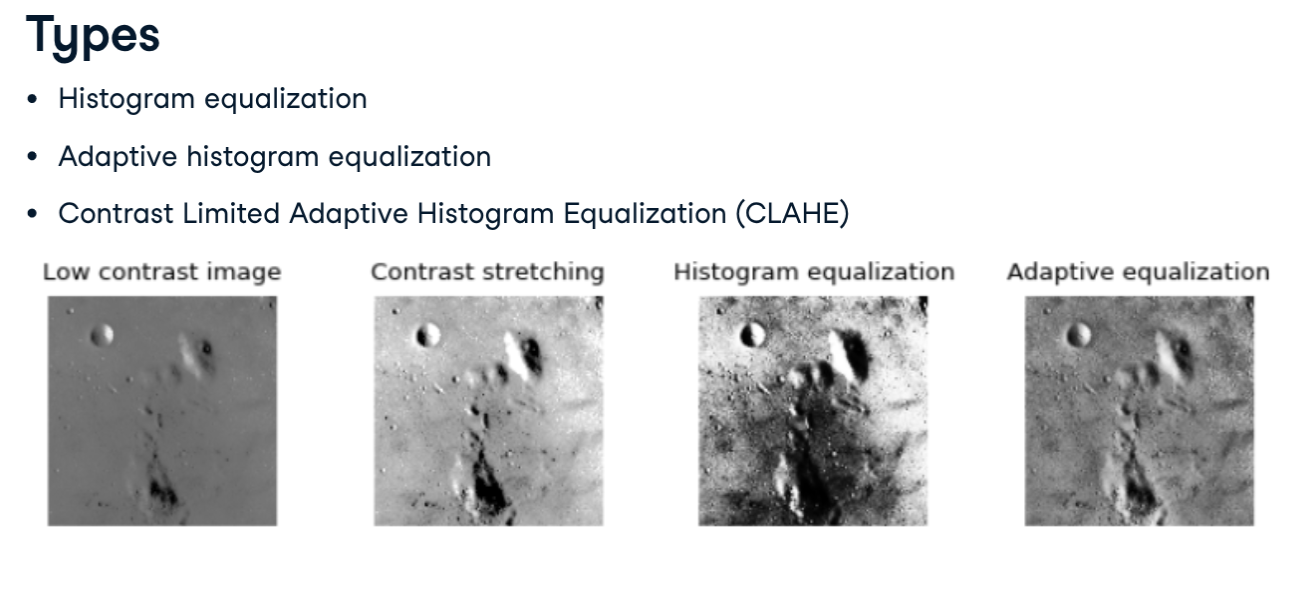

In [16]:
chest_xray_image = plt.imread("chest_xray_image.png")

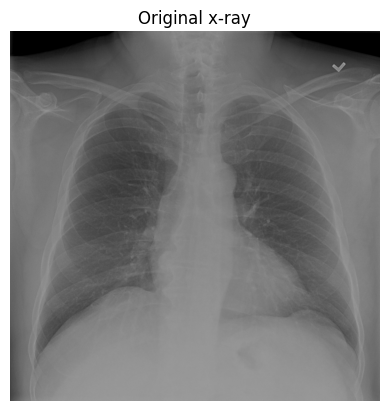

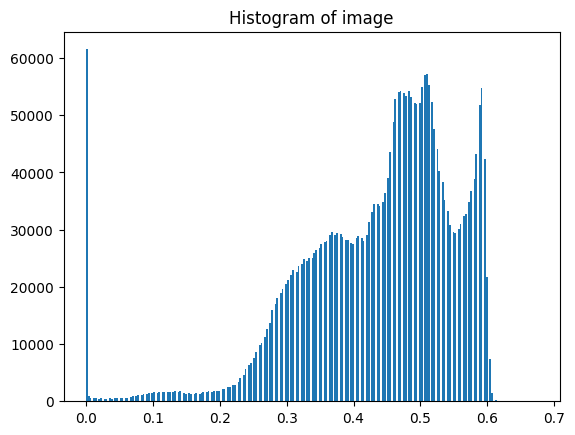

/home/shk/Documents/projects/python/ML/DataCamp/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:587: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


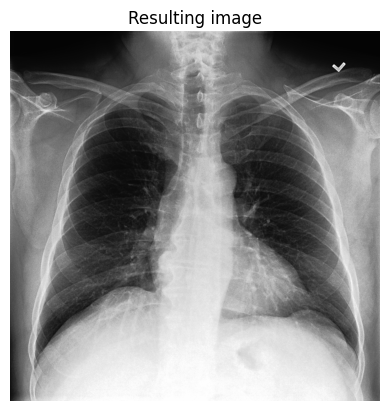

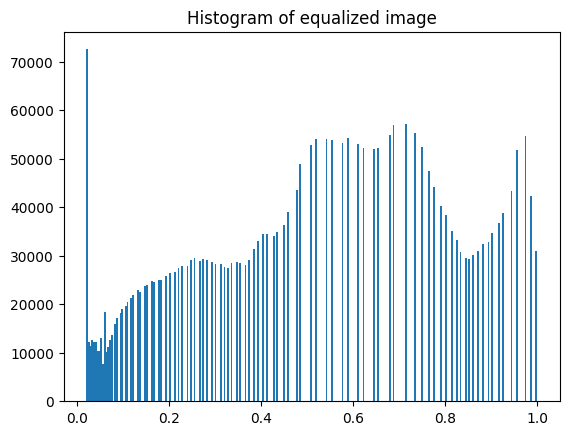

In [18]:
# Import the required module
from skimage import exposure

# Show original x-ray image and its histogram
show_image(chest_xray_image, 'Original x-ray')

plt.title('Histogram of image')
plt.hist(chest_xray_image.ravel(), bins=256)
plt.show()

# Use histogram equalization to improve the contrast
xray_image_eq =  exposure.equalize_hist(chest_xray_image)

# Show the resulting image
show_image(xray_image_eq, 'Resulting image')

plt.title('Histogram of equalized image')
plt.hist(xray_image_eq.ravel(), bins=256)
plt.show()

### Aerial image
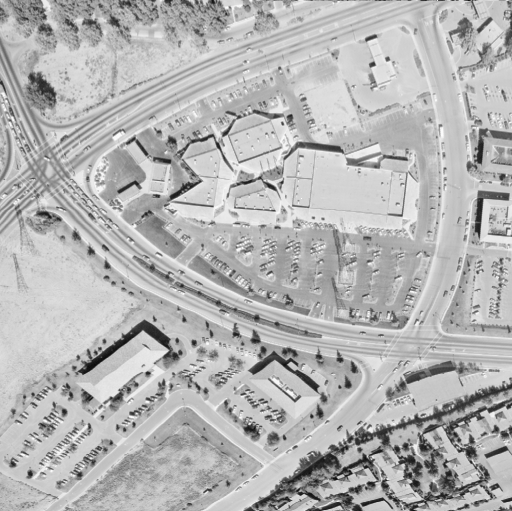


In [19]:
image_aerial = plt.imread("image_aerial.png")

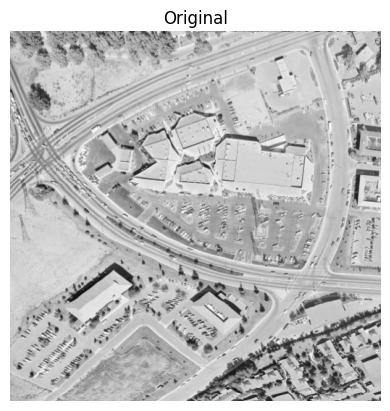

<Figure size 640x480 with 0 Axes>

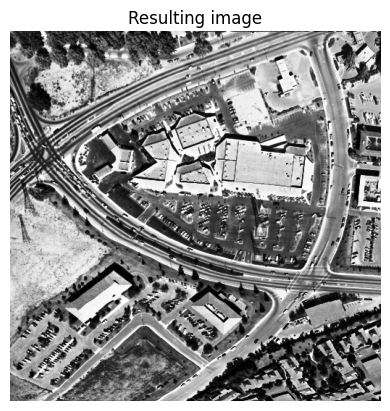

<Figure size 640x480 with 0 Axes>

In [20]:
# Import the required module
from skimage import exposure

# Use histogram equalization to improve the contrast
image_eq =  exposure.equalize_hist(image_aerial)

# Show the original and resulting image
show_image(image_aerial, 'Original')
show_image(image_eq, 'Resulting image')

### Let's add some impact and contrast


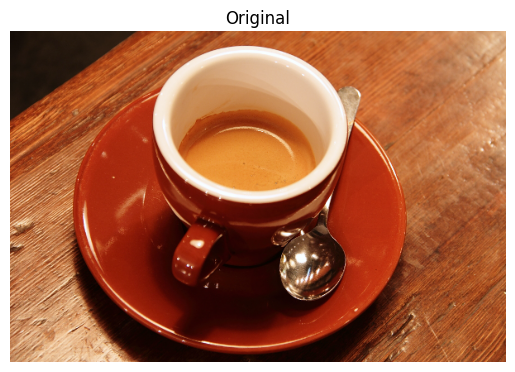

<Figure size 640x480 with 0 Axes>

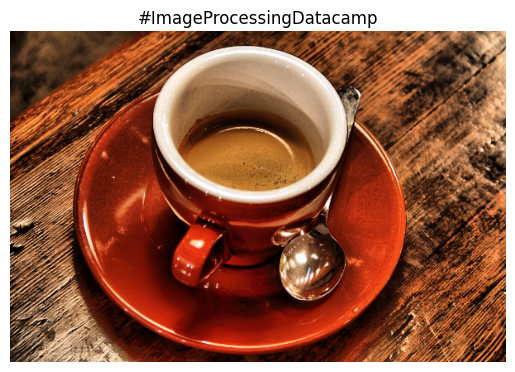

<Figure size 640x480 with 0 Axes>

In [21]:
# Import the necessary modules
from skimage import data, exposure

# Load the image
original_image = data.coffee()

# Apply the adaptive equalization on the original image
adapthist_eq_image = exposure.equalize_adapthist(original_image, clip_limit=0.03)

# Compare the original image to the equalized
show_image(original_image)
show_image(adapthist_eq_image, '#ImageProcessingDatacamp')

## Transformations

In [10]:
import skimage
import matplotlib.pyplot as plt

img = "image_cat.png"
image_cat = plt.imread(img)


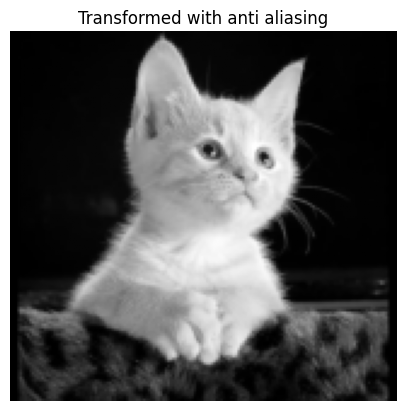

<Figure size 640x480 with 0 Axes>

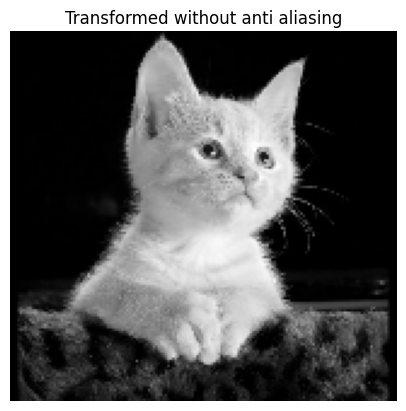

<Figure size 640x480 with 0 Axes>

In [11]:
# Import the module and the rotate and rescale functions
from skimage.transform import rotate, rescale

# Rotate the image 90 degrees clockwise 
rotated_cat_image = rotate(image_cat, -90)

# Rescale with anti aliasing
rescaled_with_aa = rescale(rotated_cat_image, 1/4, anti_aliasing=True)

# Rescale without anti aliasing
rescaled_without_aa = rescale(rotated_cat_image, 1/4, anti_aliasing=False)

# Show the resulting images
show_image(rescaled_with_aa, "Transformed with anti aliasing")
show_image(rescaled_without_aa, "Transformed without anti aliasing")

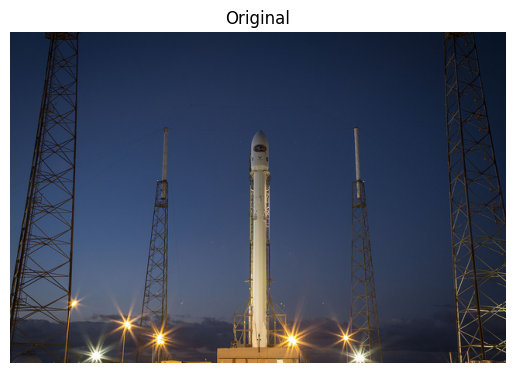

<Figure size 640x480 with 0 Axes>

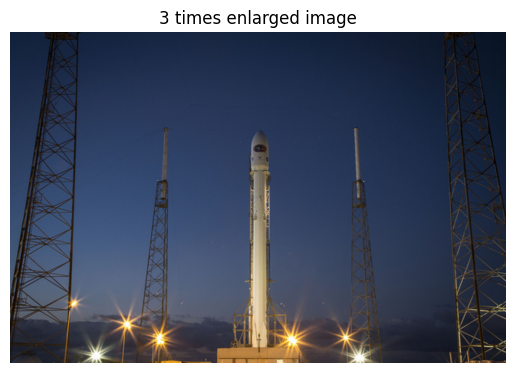

<Figure size 640x480 with 0 Axes>

In [ ]:
# Rescaling (enlarge)

# Import the module and function to enlarge images
from skimage.transform import rescale

# Import the data module
from skimage import data

# Load the image from data
rocket_image = data.rocket()
# Enlarge the image so it is 3 times bigger
enlarged_rocket_image = rescale(
    rocket_image, 3, anti_aliasing=True, channel_axis=-1, preserve_range=True
).astype("uint8")

# Show original and resulting image
show_image(rocket_image)
# Recompute with a proper channel axis so RGB stays 3 channels
show_image(enlarged_rocket_image, "3 times enlarged image")

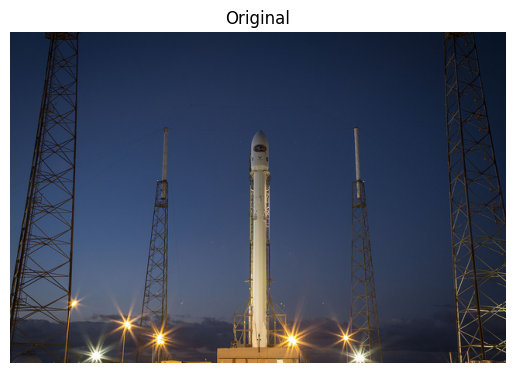

<Figure size 640x480 with 0 Axes>

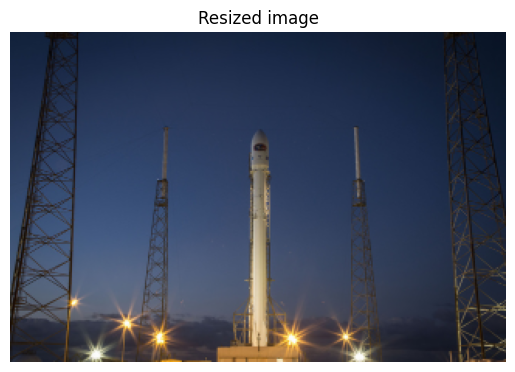

<Figure size 640x480 with 0 Axes>

In [23]:
# resize
# Import the module and function
from skimage.transform import resize

# Set proportional height so its half its size
height = int(rocket_image.shape[0] / 2)
width = int(rocket_image.shape[1] / 2)

# Resize using the calculated proportional height and width
image_resized = resize(rocket_image, (height, width),
                       anti_aliasing=True)

# Show the original and resized image
show_image(rocket_image, 'Original')
show_image(image_resized, 'Resized image')

1. Morphology

    When you try to spot objects in an image, you can do so by its characteristics, like the shape. This what Morphology does.

2. Binary images

    Binary regions produced by simple thresholding can be distorted by noise and texture, as we can see in the image.   

3. Morphological filtering

    Morphological filtering operations try to remove these imperfections by accounting for the form and structure of the objects in the image. These operations are especially suited to binary images, but some can extend to grayscale ones.

4. Morphological operations

    Basic morphological operations are dilation and erosion. Dilation adds pixels to the boundaries of objects in an image, while erosion removes pixels on object boundaries. The number of pixels added or removed from the objects in an image depends on the size and shape of a structuring element used to process the image.

    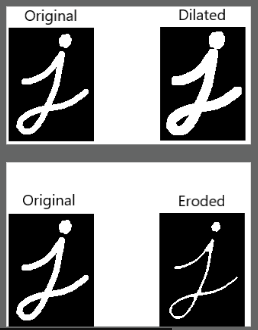

# Image restoration, Noise, Segmentation and Contours

In [ ]:
# Import the module from restoration
from skimage.restoration import inpaint

# Show the defective image
show_image(defect_image, 'Image to restore')

# Apply the restoration function to the image using the mask
restored_image = inpaint.inpaint_biharmonic(defect_image, mask, multichannel=True)
show_image(restored_image)

In [13]:
!pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.restoration import inpaint
import cv2 as cv

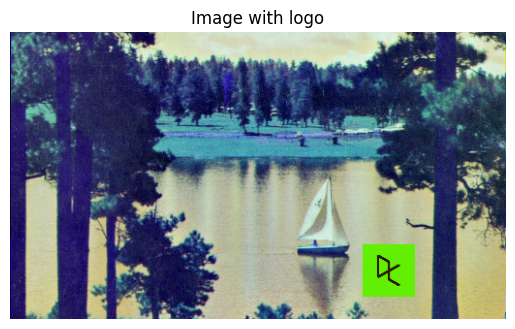

<Figure size 640x480 with 0 Axes>

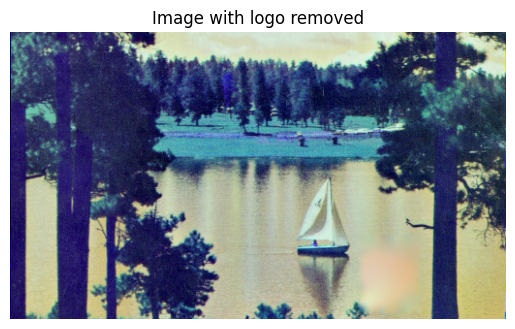

<Figure size 640x480 with 0 Axes>

In [22]:
image_with_logo = cv.imread('image_with_logo.png')
# Initialize the mask
mask = np.zeros(image_with_logo.shape[:-1])
# Set the pixels where the logo is to 1
mask[210:290, 360:425] = 1

# Apply inpainting to remove the logo
image_logo_removed = inpaint.inpaint_biharmonic(
    image_with_logo,
    mask.astype(bool),
    channel_axis=-1
)

# Show the original and logo removed images
show_image(image_with_logo, 'Image with logo')
show_image(image_logo_removed, 'Image with logo removed')

Recap:

**Inpainting Basics**: You discovered that inpainting is used to fix damaged images, remove unwanted text, logos, or objects like tattoos from photos. This technique is crucial for restoring cherished memories or modifying images for various purposes.

**Using scikit-image for Inpainting**: You explored how to apply inpainting in Python using the inpaint_biharmonic function from the scikit-image library's restoration module. This function requires a mask image to identify the damaged pixels that need filling.

**Creating a Mask Image**: You learned that a mask image is essential for inpainting, where damaged or unwanted areas are marked with non-zero pixel intensity values. This mask guides the inpainting algorithm on where to focus its restoration efforts.

**Practical Application**: Through exercises, you practiced restoring an image with missing parts and removing a logo from an image. You initialized a mask with np.zeros() and set specific regions to 1 to indicate areas needing inpainting. Then, you applied the inpaint_biharmonic function, specifying whether the image was colored with the multichannel=True parameter.



## Noise

In [13]:
import skimage

cat_image = skimage.data.cat()

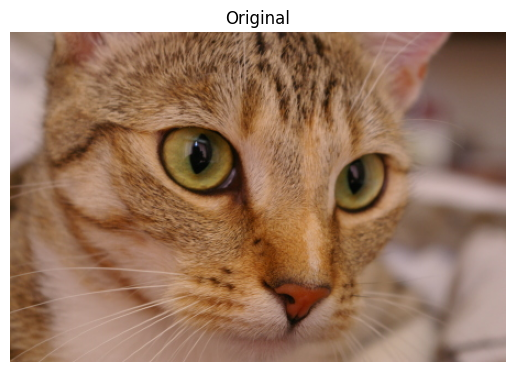

<Figure size 640x480 with 0 Axes>

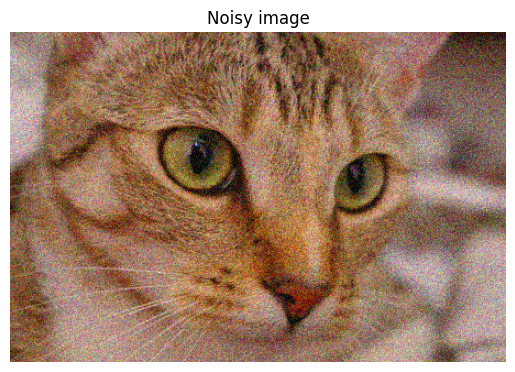

<Figure size 640x480 with 0 Axes>

In [ ]:
# Import the module and function
from skimage.util import random_noise

# Add noise to the image
noisy_image = random_noise(cat_image)

# Show original and resulting image
show_image(cat_image, 'Original')
show_image(noisy_image, 'Noisy image')

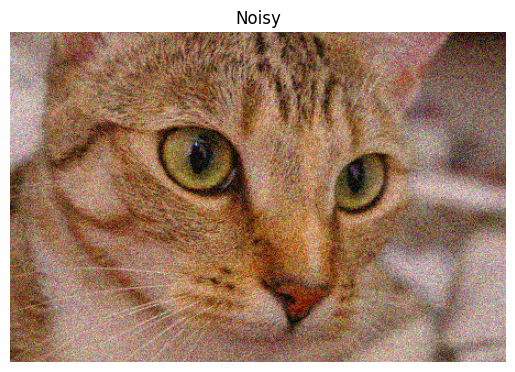

<Figure size 640x480 with 0 Axes>

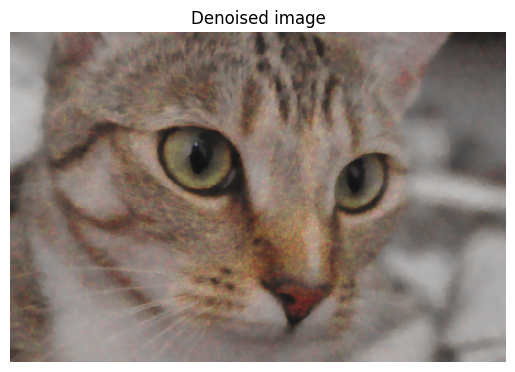

<Figure size 640x480 with 0 Axes>

In [8]:
# Import the module and function
from skimage.restoration import denoise_tv_chambolle

# Apply total variation filter denoising
denoised_image = denoise_tv_chambolle(noisy_image)

# Show the noisy and denoised images
show_image(noisy_image, 'Noisy')
show_image(denoised_image, 'Denoised image')

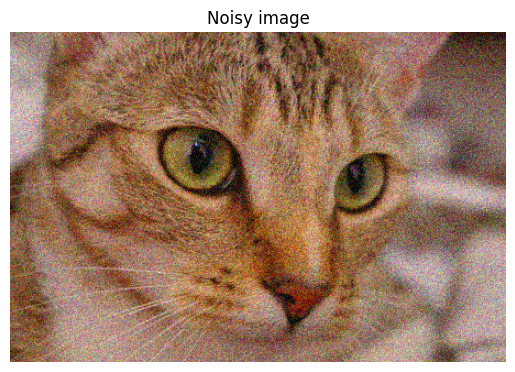

<Figure size 640x480 with 0 Axes>

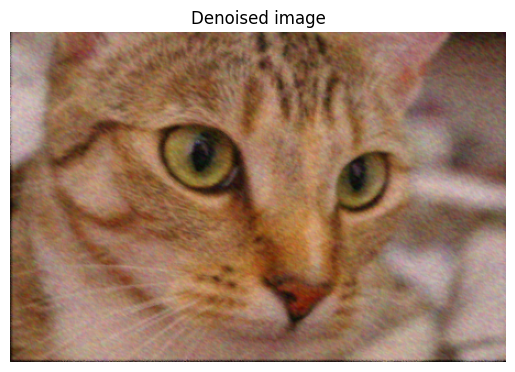

<Figure size 640x480 with 0 Axes>

In [11]:
# Import bilateral denoising function
from skimage.restoration import denoise_bilateral

# Apply bilateral filter denoising
denoised_image = denoise_bilateral(noisy_image, channel_axis=-1)

# Show original and resulting images
show_image(noisy_image, 'Noisy image')
show_image(denoised_image, 'Denoised image')

## SuperPixels and Segmentation
1. Superpixels

    Superpixels are groups of pixels that share similar characteristics, such as color or texture. They are used to simplify image processing tasks by reducing the number of elements to analyze while preserving important information.
2. Segmentation

    Image segmentation is the process of partitioning an image into multiple segments or regions, often to simplify or change the representation of an image into something more meaningful and easier to analyze. It is commonly used in various applications, including object recognition, medical imaging, and autonomous vehicles.

In [32]:
cat_image.shape[0] * cat_image.shape[1]

135300

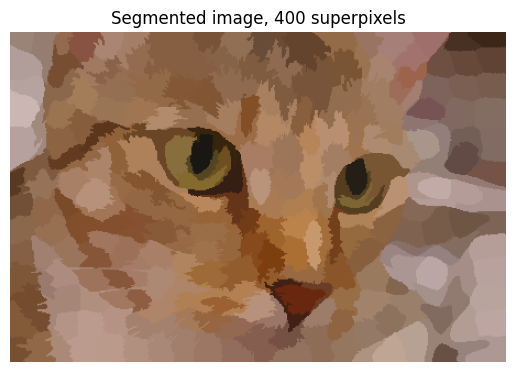

<Figure size 640x480 with 0 Axes>

In [31]:
# Import the slic function from segmentation module
from skimage.segmentation import slic
# Import the label2rgb function from color module
from skimage.color import label2rgb

# Obtain the segmentation with 400 regions
segments = slic(cat_image, n_segments=300)

# Put segments on top of original image to compare
segmented_image = label2rgb(segments, cat_image, kind='avg')

# Show the segmented image
show_image(segmented_image, "Segmented image, 400 superpixels")

## Find Contours



In [1]:
import matplotlib.pyplot as plt

In [2]:
def show_image_contour(image, contours):
    plt.figure(),
    for n, contour in enumerate(contours):
        plt.plot(contour[:, 1], contour[:, 0], linewidth=3)
    plt.imshow(image, interpolation='nearest', cmap='gray_r')
    plt.title('Contours')
    plt.axis('off')
    plt.show()


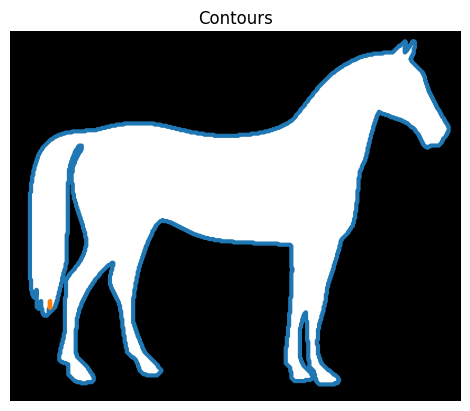

In [3]:
# Import the modules
from skimage import data, measure

# Obtain the horse image
horse_image = data.horse()

# Find the contours with a constant level value of 0.8
contours = measure.find_contours(horse_image, 0.8)

# Shows the image with contours found
show_image_contour(horse_image, contours)

In [4]:
import skimage
from skimage import filters,measure,color

In [5]:
pip install pooch --break-system-packages

Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_2411741/218975470.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(img)


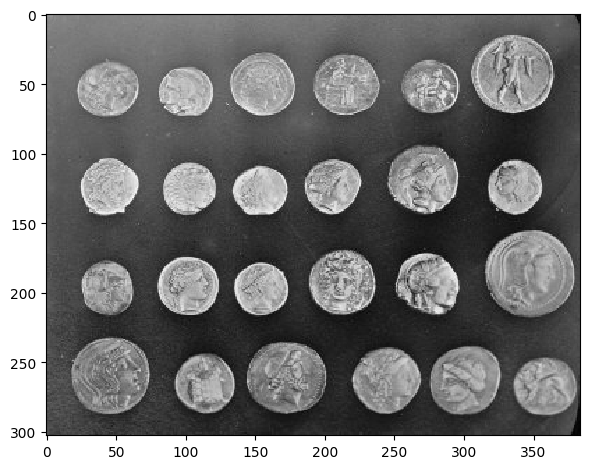

In [11]:
img = skimage.data.coins()
skimage.io.imshow(img)

In [15]:
# Make the image grayscale
if img.shape[-1] == 3:
    img = color.rgb2gray(img)

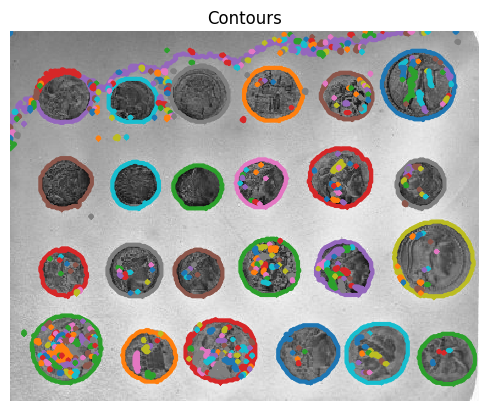

In [ ]:
# Obtain the optimal thresh value
thresh = skimage.filters.threshold_otsu(img,)

# Apply thresholding
binary = img > thresh

# Find contours at a constant value of 0.8
contours = measure.find_contours(binary, .8)

# Show the image
show_image_contour(img, contours)

# Advanced Operations, Detecting Faces and Features

## Edge detection

Edge detection is a technique used in image processing to identify and locate sharp discontinuities in an image. These discontinuities typically correspond to the boundaries of objects within the image. Edge detection is a fundamental step in many computer vision applications, such as object recognition, image segmentation, and feature extraction.

### Canny edge detection
The Canny edge detection algorithm is a popular and widely used method for edge detection. It consists of several steps:
1. **Noise Reduction**: The image is first smoothed using a Gaussian filter to reduce noise and prevent false edge detection.
2. **Gradient Calculation**: The algorithm computes the intensity gradient of the image using techniques like the Sobel operator. This step identifies areas of rapid intensity change, which are potential edges.
3. **Non-Maximum Suppression**: This step thins the edges by suppressing non-maximum pixels in the gradient direction, resulting in thin edges.
4. **Double Thresholding**: The algorithm applies two thresholds to classify edges as strong, weak, or non-edges. Strong edges are retained, while weak edges are only retained if they are connected to strong edges.
5. **Edge Tracking by Hysteresis**: Finally, the algorithm tracks edges by connecting weak edges to strong edges, resulting in a final edge map.

In [ ]:
import skimage

coins = skimage.data.coins()

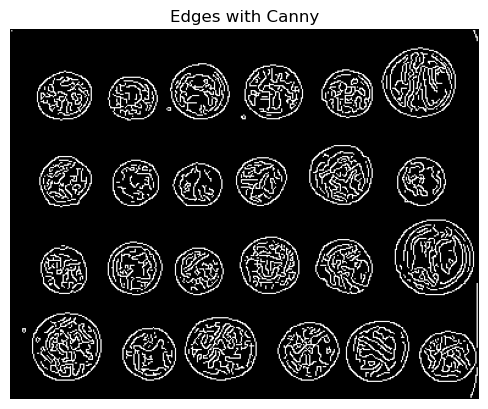

<Figure size 640x480 with 0 Axes>

In [ ]:
# Import the canny edge detector 
from skimage.feature import canny
from skimage import color
import matplotlib.pyplot as plt

# Convert image to grayscale
# coins = color.rgb2gray(coins)

# Apply canny edge detector
canny_edges = canny(coins)

# Show resulting image
show_image(canny_edges, "Edges with Canny")

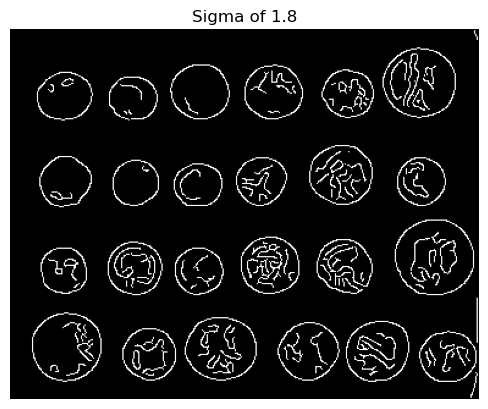

<Figure size 640x480 with 0 Axes>

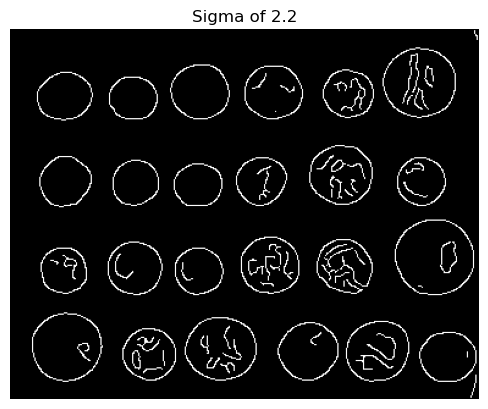

<Figure size 640x480 with 0 Axes>

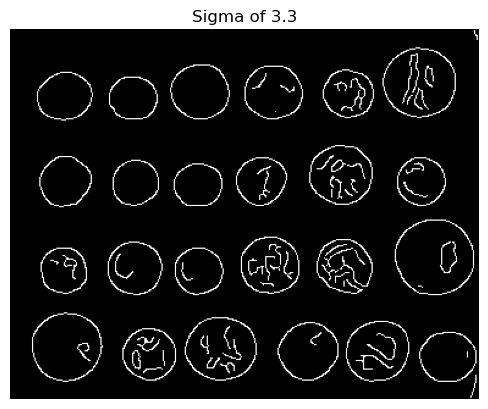

<Figure size 640x480 with 0 Axes>

In [ ]:
# Apply canny edge detector with a sigma of 1.8
edges_1_8 = canny(coins, sigma=1.8)

# Apply canny edge detector with a sigma of 2.2
edges_2_2 = canny(coins, sigma=2.2)

edges_3_3 = canny(coins, sigma=3.3)

# Show resulting images
show_image(edges_1_8, "Sigma of 1.8")
show_image(edges_2_2, "Sigma of 2.2")
show_image(edges_2_2, "Sigma of 3.3")